# Messy Crime Incident Dataset for Data Cleaning Practice

## Goal and description of this script 

This dataset contains simulated crime incidents reported across different districts and cities, designed specifically for **data cleaning and preprocessing practice**. Each row corresponds to a single incident with details about the crime, suspect information, reporting method, and investigation status. The data intentionally includes inconsistencies, missing values, duplicates, and formatting issues to mimic real-world messy datasets.


In [2]:
# import libraries and read in the dataset
import pandas as pd
from pathlib import Path

dataset = Path(r"C:\Users\EMI-M\OneDrive\Lauriane\Informatique\Self_training - Portfolio\Kaggle data _ clean\crime_incidents_messy.csv")
df = pd.read_csv(dataset, sep=",", encoding="utf-8-sig", skipinitialspace=True, on_bad_lines="warn")

print(df.head(10))
#df.shape
num = df.select_dtypes("number")
summary = pd.DataFrame({
    "types": df.apply(lambda s: ", ".join(sorted({type(v).__name__ for v in s.dropna()}))),
    "na": df.isna().sum()})
print(summary)

# Remove rows with all NaN values and duplicates
df.isna().all(axis=1).sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.shape

# remove spaces from string columns and convert to lowercase
text_cols = df.select_dtypes("object").columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())   # spaces removed from the beginning and end of strings
df[text_cols] = df[text_cols].apply(lambda s: s.str.lower())  # avoids duplicates due to case differences
df[text_cols] = df[text_cols].apply(lambda s: s.str.replace(r"\s+", " ", regex=True)) # collapse double spaces

  incident_id           crime_type     district         city state  \
0   INC001115                asslt          Sou    Maplewood    GA   
1   INC004706             burglary    southeast    Maplewood    OH   
2   INC002249             Homocide  Southwest       Lakewood    AZ   
3   INC000021      Property Damage          Cen  Springfield    AZ   
4   INC000488     Domestc Violence        North     Lakewood    PA   
5   INC000661  Breaking & Entering       East      Hillcrest    CA   
6   INC001727              robbery    southeast    Maplewood    TX   
7   INC003981         manslaughter      midtown  Centerville    IL   
8   INC001205                  B&E       East    Centerville    OH   
9   INC000972             Homocide    northeast    Riverside    IL   

               address    latitude   longitude    incident_datetime  \
0      2830 Cedar Lane  170.284100  -77.500710  2024-04-16 08:45:03   
1         2361 Park Rd   29.422717  -77.167016  2022-01-11 22:03:29   
2         1067 M

## Datatype correction

In [3]:
# change badge number datatype to string, but keep NaN values as <NA>
df["badge_number"] = df["badge_number"].astype("Int64").astype("string")

# convert property loss to numeric; non-numeric values become NaN instead of raising an error
df["property_loss_usd"] = pd.to_numeric(df["property_loss_usd"], errors="coerce")

## Cleaning of categorical values

### Typo correction and category harmonization

Typos create extra categories: the same value spelled differently is counted as two distinct categories. Identifying and correcting them is essential to avoid these duplicates. With more than 5,000 rows, a manual check would take too long, so I automated the detection of close matches. I then reviewed each proposed correction and manually adjusted the ones that were wrong.

In [4]:
# Look at the values in the categorical columns to identify potential typos or inconsistencies
cat_cols = df.select_dtypes(["object", "string"]).columns

for c in cat_cols:
    print(f"\n{c} ({df[c].nunique()} unique)")
    print(df[c].value_counts(dropna=False).head(10).to_string())

import difflib

# Create a mapping of old values to new values
mappings = {}
for c in text_cols:
    counts = df[c].value_counts()
    if len(counts) > 100:
        continue
    kept, mapping = [], {}
    for v in counts.index:
        match = difflib.get_close_matches(v, kept, n=1, cutoff=0.85)
        if match:
            mapping[v] = match[0]
        else:
            kept.append(v)
    if mapping:
        mappings[c] = mapping

for c, mapping in mappings.items():
    counts = df[c].value_counts()
    print(f"\n{c}")
    for old, new in mapping.items():
        print(f"  {old!r} ({counts[old]}) → {new!r} ({counts[new]})")

# Remove the mappings that are not relevant for cleaning the data      
del mappings["district"]["northwest"] 
del mappings["district"]["southeast"]

# fix reversed direction (the typo was more frequent)
mappings["case_status"] = {"pendng": "pending"}

# apply changes 
for c, mapping in mappings.items():
    df[c] = df[c].replace(mapping)

print ("\n")

# check it worked
for c, mapping in mappings.items():
    left = df[c].isin(mapping.keys()).sum()
    print(c, "remaining old values:", left)



incident_id (5050 unique)
incident_id
inc003216    1
inc001115    1
inc004706    1
inc002249    1
inc000021    1
inc000488    1
inc000661    1
inc001727    1
inc003981    1
inc001205    1

crime_type (58 unique)
crime_type
theft             209
trespassing       200
arson             196
kidnapping        193
fraud             182
burglary          171
homicide          170
sexual assault    168
robbery           166
cyber crime       158

district (16 unique)
district
southwest    444
west         442
northeast    436
central      427
north        424
midtown      421
south        411
northwest    407
southeast    391
east         379

city (8 unique)
city
riverside      705
centerville    661
lakewood       641
springfield    633
oakdale        608
maplewood      604
hillcrest      604
fairview       594

state (10 unique)
state
fl    536
az    527
tx    517
il    511
ny    510
pa    509
nc    493
ga    489
ca    481
oh    477

address (4895 unique)
address
8687 maple dr       3
649

### Harmonizing category synonyms

The similarity check above cannot catch every duplicate category: it misses abbreviations and synonyms, whose spelling is too different. For example, "sa" stands for "sexual assault", and "narcotics" means the same as "drug offense". This step cannot be automated and had to be done manually.


In [5]:
cols = ["district", "crime_type", "weapon_used", "severity",
        "case_status", "resolution", "reported_online"]

unique_table = pd.DataFrame(
    {c: pd.Series(sorted(df[c].dropna().unique(), key=str)) for c in cols}
).fillna("")
unique_table

#group synonyms
synonyms = {
    "district": {
        "central": ["cen"],
        "midtown": ["mid"],
        "north": ["nor"],
        "south": ["sou"],
    },
    "crime_type": {

    # Crimes against persons
    "person-related": [
        "homicide", "murder", "manslaughter",
        "assault", "asslt", "battery", "assault & battery",
        "sexual assault", "sa",
        "kidnapping", "abduction",
        "domestic violence", "dom. violence", "dv"
    ],

    # Property crimes
    "property": [
        "theft", "theft/larceny", "larceny", "stealing",
        "burglary", "b&e", "breaking & entering",
        "robbery", "armed robbery",
        "arson", "arsen", "fire setting",
        "vandalism", "graffiti", "property damage"
    ],

    # Financial / cyber crimes
    "financial / cyber": [
        "fraud", "scam", "deception", "fraudulent activity",
        "cyber crime", "hacking", "online fraud"
    ],

    # Public order / society
    "public order / society": [
        "drug offense", "drugs", "narcotics",
        "dui", "d.u.i.", "dwi", "drunk driving",
        "trespassing", "trespass"]
    },
    "severity": {  
          "1" : ["low"],
          "2" : ["medium", "med"],
          "3" : ["high"],
          "4" : ["critical", "crit"]
    },
    "case_status": {
        "under investigation": ["investgation"],
    },
    "resolution": {
        "warning": ["warning issued"],
        "dismissed": ["case dismissed"],
    },
    "weapon_used": {
       "firearm" : ["gun", "rifle", "pistol"],
        "unarmed" : ["hands/feet", "hands"],
        "blunt object" : ["bat"]
    },
    "reported_online": {
        "yes": ["1", "true"],
        "no": ["0", "false"]    
}}

for col, groups in synonyms.items():
    mapping = {old: new for new, olds in groups.items() for old in olds}
    df[col] = df[col].replace(mapping)
    print(col, df[col].nunique(), sorted(df[col].dropna().unique()))

# change unknown category into NaN
df["suspect_race"] = (
    df["suspect_race"]
    .astype("string")
    .replace("unknown", pd.NA)
)

district 10 ['central', 'east', 'midtown', 'north', 'northeast', 'northwest', 'south', 'southeast', 'southwest', 'west']
crime_type 4 ['financial / cyber', 'person-related', 'property', 'public order / society']
severity 4 ['1', '2', '3', '4']
case_status 5 ['closed', 'open', 'pending', 'resolved', 'under investigation']
resolution 4 ['arrest made', 'dismissed', 'no arrest', 'warning']
weapon_used 4 ['blunt object', 'firearm', 'knife', 'unarmed']
reported_online 2 ['no', 'yes']


### Missing gender values

Missing values are always a challenge because we want to avoid losing information. For the victim and suspect gender columns, the missing values can be imputed from the first name columns. However, with more than 5,000 rows, filling them manually would be too time-consuming. Fortunately, a package (`gender-guesser`) can guess gender from first names. It also returns a category for ambiguous names ("mostly male" or "mostly female"). I reviewed this category and decided which names were truly ambiguous. All imputed values are flagged.

In [6]:
# Handling missing data : victim and suspect gender
import gender_guesser.detector as gender

d = gender.Detector(case_sensitive=False)
labels = {"male": "male", "mostly_male": "male",
          "female": "female", "mostly_female": "female"}

for role in ["victim", "suspect"]:
    first, gcol = f"{role}_first_name", f"{role}_gender"
    flag, unc = f"{role}_gender_imputed", f"{role}_gender_uncertain"
    print(f"\n===== {role} =====")

    df[gcol] = df[gcol].replace({"m": "male", "f": "female"})
    print(df[gcol].value_counts(dropna=False))

    missing = df[first].notna() & (df[gcol].isna() | (df[gcol] == "unknown"))

    # guess the gender based on the first name
    raw = df.loc[missing, first].apply(d.get_gender)
    guess = raw.map(labels).dropna()
    uncertain = raw[raw.str.startswith("mostly")].index   # "mostly_..." guesses

    for f in [flag, unc]:   # avoids resetting the flags on rerun
        if f not in df.columns:
            df[f] = False
    df.loc[guess.index, gcol] = guess
    df.loc[guess.index, flag] = True
    df.loc[uncertain, unc] = True

    print("filled:", len(guess), "/", missing.sum(), "| uncertain:", len(uncertain))
    print(df[gcol].value_counts(dropna=False))

    left = df[first].notna() & (df[gcol].isna() | (df[gcol] == "unknown"))
    print(df.loc[left, first].map(d.get_gender).value_counts())

for role in ["victim", "suspect"]:
    unc = f"{role}_gender_uncertain"
    print(f"\n===== {role} =====")
    print(df.loc[df[unc]]
            .groupby(f"{role}_first_name")[f"{role}_gender"]
            .agg(["first", "count"])
            .to_string())
print ("\n")

# manually confirmed names: no longer uncertain
confirmed = ["mary", "carol"]

for role in ["victim", "suspect"]:
    unc = f"{role}_gender_uncertain"
    ok = df[unc] & df[f"{role}_first_name"].isin(confirmed)
    df.loc[ok, unc] = False
    print(role, "confirmed:", ok.sum(), "| still uncertain:", df[unc].sum())


===== victim =====
victim_gender
male       1751
female     1615
NaN         963
unknown     367
other       354
Name: count, dtype: int64
filled: 1082 / 1082 | uncertain: 145
victim_gender
male      2300
female    2148
other      354
NaN        248
Name: count, dtype: int64
Series([], Name: count, dtype: int64)

===== suspect =====
suspect_gender
female     1578
male       1509
NaN        1352
other       306
unknown     305
Name: count, dtype: int64
filled: 882 / 882 | uncertain: 115
suspect_gender
female    2003
male      1966
NaN        775
other      306
Name: count, dtype: int64
Series([], Name: count, dtype: int64)

===== victim =====
                    first  count
victim_first_name               
ashley             female     32
carol              female     36
chris                male     38
mary               female     39

===== suspect =====
                     first  count
suspect_first_name               
ashley              female     24
carol               female  

## Cleaning of numeric values

### Data distribution overview
For numeric variables, inconsistencies can be detected by looking at the data distribution and range. For each float column, I computed the minimum, maximum, median, mean and standard deviation, and compared them with realistic values for each variable. The first evident inconsistency was the presence of negative values. Except for Longitude and latitude, it does not make sense.

One of the biggest questions when cleaning data is how to handle missing values: remove these rows or impute them with the median? When more than about 5% of values are missing, median imputation is generally not recommended, because it distorts the distribution. Missing value percentage for number of arrests and property loss are above 5% and values aren't imputable from other columns, Therefore I let them as they are.

In [7]:
# Identify the numeric columns and compute summary statistics 
num_cols = df.select_dtypes("float").columns
stats = df[num_cols].agg(["min", "max", "median", "mean", "std"]).T
stats["missing_%"] = df[num_cols].isna().mean() * 100
print(stats.round(2))

# Make all numeric values positive except longitude (which can be negative in the Western Hemisphere)
for col in num_cols.drop("longitude"):
    df[col] = df[col].abs()

# round all numeric values to 2 decimal places
df[num_cols] = df[num_cols].round(2)

                        min       max    median      mean       std  missing_%
latitude              25.00    199.98     36.97     40.74     23.19       4.97
longitude           -121.98     99.79    -94.67    -88.75     37.04       5.50
suspect_age          -75.00    298.00     46.00     48.56     43.70      20.83
victim_age           -90.00    298.00     49.00     52.23     47.83      10.73
num_arrests           -5.00      5.00      2.00      2.26      1.99       6.42
property_loss_usd -49866.74  49998.30  23630.90  22774.69  17586.03      10.89


### Inconsistent age

Some victim and suspect ages were unrealistically high (above 100). Before setting them to NaN, I checked whether any ages were close to 100. Since there were none, there was no risk of excluding a very old person, so all ages above 100 were set to NaN.
Since 10.7% of victim ages and 20.8% of suspect ages were missing in the original data (see table above), and even more after the invalid ages were set to NaN, I left them as NaN.

In [8]:
import numpy as np

print("====== Victim and suspect ages ======")

# Check for outliers in the age columns
for c in ["victim_age", "suspect_age"]:
    print(c, (df[c] > 100).sum())
    print(df.loc[df[c] > 100, c].value_counts().sort_index())

print("\n")

# replace the outliers with NaN
for c in ["victim_age", "suspect_age"]:
    df.loc[df[c] > 100, c] = pd.NA


====== Victim and suspect ages ======
victim_age 175
victim_age
150.0    1
151.0    2
152.0    3
153.0    1
157.0    1
        ..
294.0    1
295.0    1
296.0    1
297.0    1
298.0    3
Name: count, Length: 103, dtype: int64
suspect_age 156
suspect_age
150.0    1
152.0    2
153.0    2
154.0    1
155.0    1
        ..
293.0    2
294.0    1
296.0    2
297.0    1
298.0    1
Name: count, Length: 100, dtype: int64




**Comment:**  A high share of missing values may also indicate that they are not missing at random. For example, some suspects may never have been identified, so their age could not be recorded.

## Inconsistent coordinates

Some coordinates fell outside the valid ranges (latitude: −90 to 90; longitude: −180 to 180). I set these invalid values to NaN, 8% of the coordinates were missing, exceeding the 5% threshold. After removing inconsistent values, the median coordinates per city were found to be very similar across cities and did not match the expected geographic ranges for these locations. 
For subsequent location-based analyses, instead of using coordinates, I can use `city` and `district` columns instead of the coordinate variables.


In [9]:

# Check for invalid coordinates (latitude: -90 to 90, longitude: -180 to 180)
bad = (df["latitude"].notna() & ~df["latitude"].between(-90, 90)) | \
      (df["longitude"].notna() & ~df["longitude"].between(-180, 180))
print("invalid coordinates:", bad.sum())
print(df.loc[bad, ["latitude", "longitude"]].head(10))

# Set invalid coordinates to NaN
df.loc[bad, ["latitude", "longitude"]] = np.nan

print("\n")

# Check the percentage of missing values
for c in ["latitude", "longitude"]:
    print(c, f"{df[c].isna().mean():.1%} missing")

# Generate a table of median, min, and max coordinates for each city
coord_tab = (
    df[["city", "longitude", "latitude"]]
    .groupby("city")
    .agg(["median", "min", "max"])
)

print(coord_tab)


invalid coordinates: 176
     latitude  longitude
0      170.28     -77.50
28     108.65     -89.44
43     163.96        NaN
93     139.96    -107.81
116    176.35        NaN
192    157.08     -94.32
212    174.04     -92.64
220    177.00    -102.53
229    134.28     -71.65
254    180.88    -115.09


latitude 8.5% missing
longitude 8.7% missing
            longitude                latitude              
               median     min    max   median    min    max
city                                                       
centerville   -95.560 -121.84  97.39   36.190  25.00  47.95
fairview      -93.770 -121.82  98.72   37.560  25.12  48.00
hillcrest     -95.370 -121.98  99.79   36.220  25.02  48.00
lakewood      -94.340 -121.98  93.95   36.130  25.10  47.99
maplewood     -93.930 -121.92  98.00   36.270  25.11  47.98
oakdale       -95.495 -121.71  98.39   37.130  25.18  47.96
riverside     -92.935 -121.86  95.63   36.645  25.02  47.98
springfield   -96.280 -121.87  99.00   36.175  25.01 

## Handling date and time column 

`incident_datetime` column gives date and sometimes time in the same cell. To be able to analyze both, they have to be separated and the best is the create 2 cells. Then, date format has to be homogenized. 
Afterwards, I will perform feature engineering to make the date and time variables more informative by transforming them into meaningful categories, i.e. season and time of day.

In [10]:
# -------------------------
# TIME
# -------------------------
# Extract time (HH:MM or HH:MM:SS)
df["incident_time"] = df["incident_datetime"].str.extract(r'([^ ]*:[^ ]*)')
print(df["incident_time"].head(10))

print("\n")

# extract hour from incident_time
hour = pd.to_numeric(df["incident_time"].str[:2], errors="coerce")   # with coerce , invalid/missing values become NaN

# Create categories
conditions = [
    (hour >= 6) & (hour < 12),
    (hour >= 12) & (hour < 18),
    (hour >= 18) & (hour < 24)
]

categories = [
    "Morning",
    "Afternoon",
    "Evening"
]

df["time_of_day"] = np.select(
    conditions,
    categories,
    default="Night"
)

# ensure that NaN values aren't converted in default "night" 
df.loc[hour.isna(), "time_of_day"] = pd.NA

print(df[["incident_time", "time_of_day"]].head(10))

# Remove the time from the original string to get the date
df["incident_date"] = (df["incident_datetime"].str.replace(r'([^ ]*:[^ ]*)', '', regex=True).str.strip())

print("\n")

# Uniform the date format : 
df["incident_date"] = pd.to_datetime(
    df["incident_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print(df["incident_date"].head(10))

# -------------------------
# DATE
# -------------------------
# Extract month-day as MM-DD
month_day = df["incident_date"].dt.strftime("%m-%d")

# create categories for the months
conditions = [
    (month_day >= "03-21") & (month_day < "06-21"),
    (month_day >= "06-21") & (month_day < "09-21"),
    (month_day >= "09-21") & (month_day < "12-21")
]

categories = [
    "Spring",
    "Summer",
    "Autumn",
]

df["season"] = np.select(
    conditions,
    categories,
    default= "Winter"
)

# ensure that NaN values aren't converted in default "Winter" 
df.loc[df["incident_date"].isna(), "season"] = pd.NA

print(df[["incident_date", "season"]].head(10))


0    08:45:03
1    22:03:29
2    11:39:24
3    15:14:24
4    20:08:13
5         NaN
6    05:17:02
7    14:49:01
8    02:37:24
9    04:16:18
Name: incident_time, dtype: object


  incident_time time_of_day
0      08:45:03     Morning
1      22:03:29     Evening
2      11:39:24     Morning
3      15:14:24   Afternoon
4      20:08:13     Evening
5           NaN        <NA>
6      05:17:02       Night
7      14:49:01   Afternoon
8      02:37:24       Night
9      04:16:18       Night


0   2024-04-16
1   2022-01-11
2   2022-04-14
3   2020-12-09
4   2021-07-24
5   2020-03-05
6   2021-10-03
7   2023-09-30
8   2021-01-22
9   2021-03-29
Name: incident_date, dtype: datetime64[ns]
  incident_date  season
0    2024-04-16  Spring
1    2022-01-11  Winter
2    2022-04-14  Spring
3    2020-12-09  Autumn
4    2021-07-24  Summer
5    2020-03-05  Winter
6    2021-10-03  Autumn
7    2023-09-30  Autumn
8    2021-01-22  Winter
9    2021-03-29  Spring


## Data visualization and exploration

### Descriptive statisitcs

Let's start the analysis with a variable overview. 
Latitude and longitude are excluded from the numeric variables. Categorical columns are manually entered due to high number of variables that I judged non relevant for the study (e.g. badge number)

In [11]:
# expand all columns and rows when displaying the dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.width", 200)

# split the dataset into numeric and categorical columns and compute summary statistics for each
numeric_cols = df.select_dtypes("number").columns.difference(["latitude", "longitude"])

numcols = df[numeric_cols].describe().round(2).T

categorical_cols = [
    "crime_type",
    "district",
    "city",
    "state",
    "suspect_gender",
    "suspect_race",
    "victim_gender",
    "weapon_used",
    "severity",
    "case_status",
    "resolution",
    "reported_online",
    "season",
    "time_of_day"
]

catcols = df[categorical_cols].describe().T

print (numcols)
print ("\n")
print (catcols)

                    count      mean       std    min       25%       50%       75%      max
num_arrests        4726.0      2.48      1.71   0.00      1.00      2.00      4.00      5.0
property_loss_usd  4500.0  24911.54  14399.55  20.66  12642.22  24698.54  37368.64  49998.3
suspect_age        3842.0     45.38     17.50  15.00     30.00     46.00     60.00     75.0
victim_age         4333.0     49.76     23.30  10.00     30.00     50.00     70.00     90.0


                count unique          top  freq
crime_type       5050      4     property  1653
district         5050     10        north   696
city             5050      8    riverside   705
state            5050     10           fl   536
suspect_gender   4275      3       female  2003
suspect_race     3162      5        black   751
victim_gender    4802      3         male  2300
weapon_used      4120      4      firearm  1539
severity         4708      4            2  1349
case_status      4354      5       closed  1099
resolution

### Data visualization

It is important to understand the distribution of each variable before performing further analyses. None of the numerical variables appear to follow a Gaussian distribution; instead, their distributions are relatively flat.

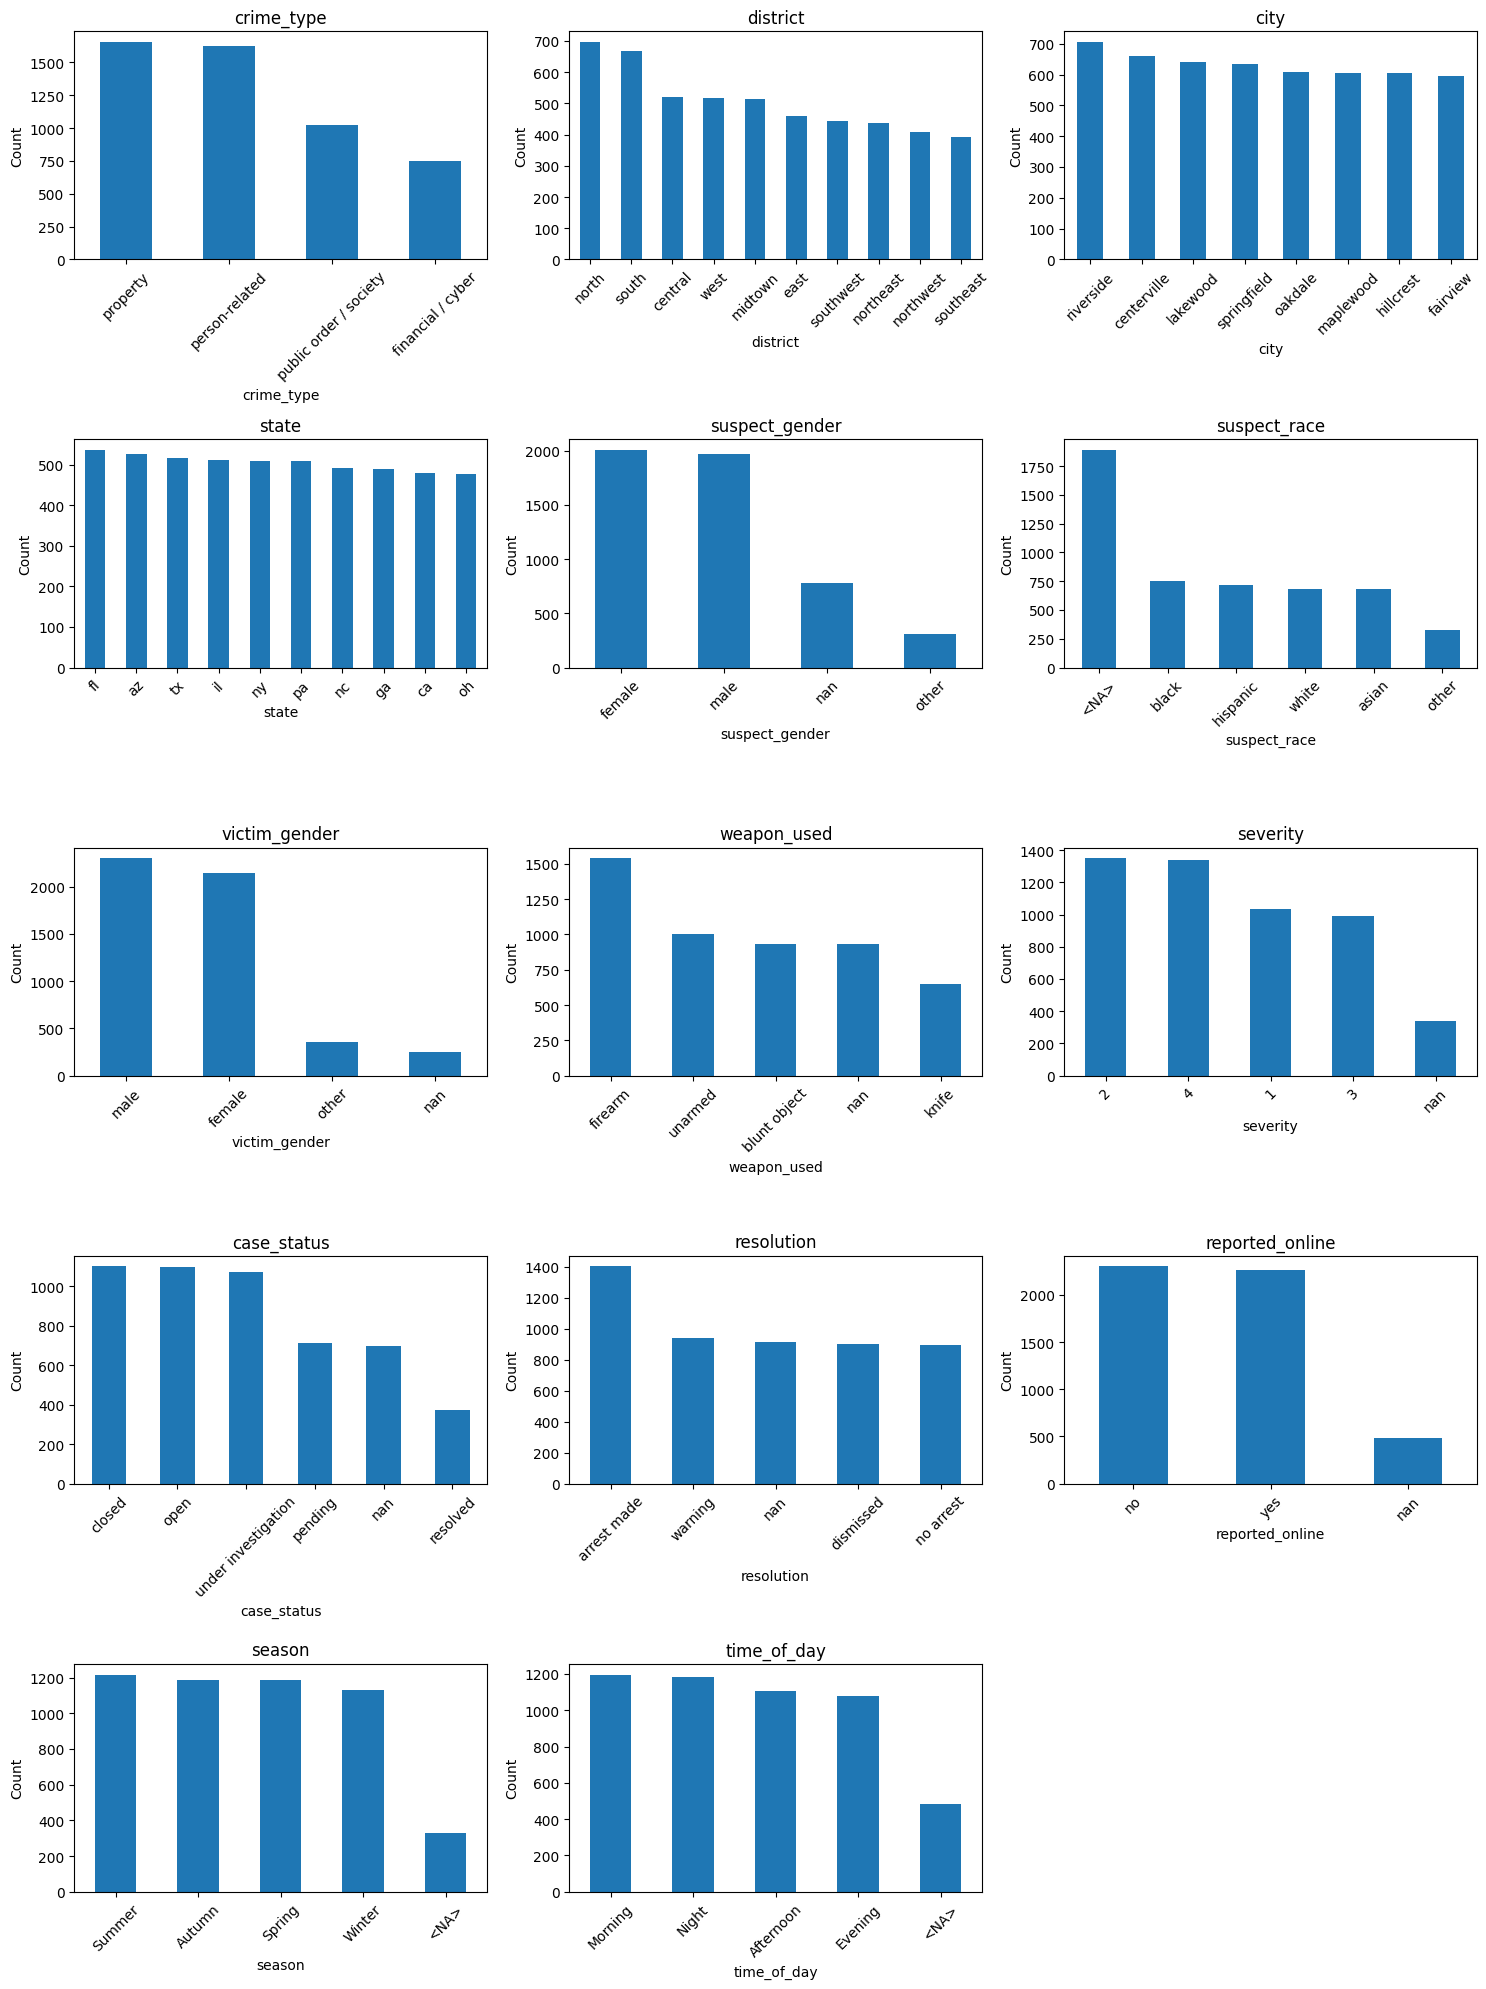

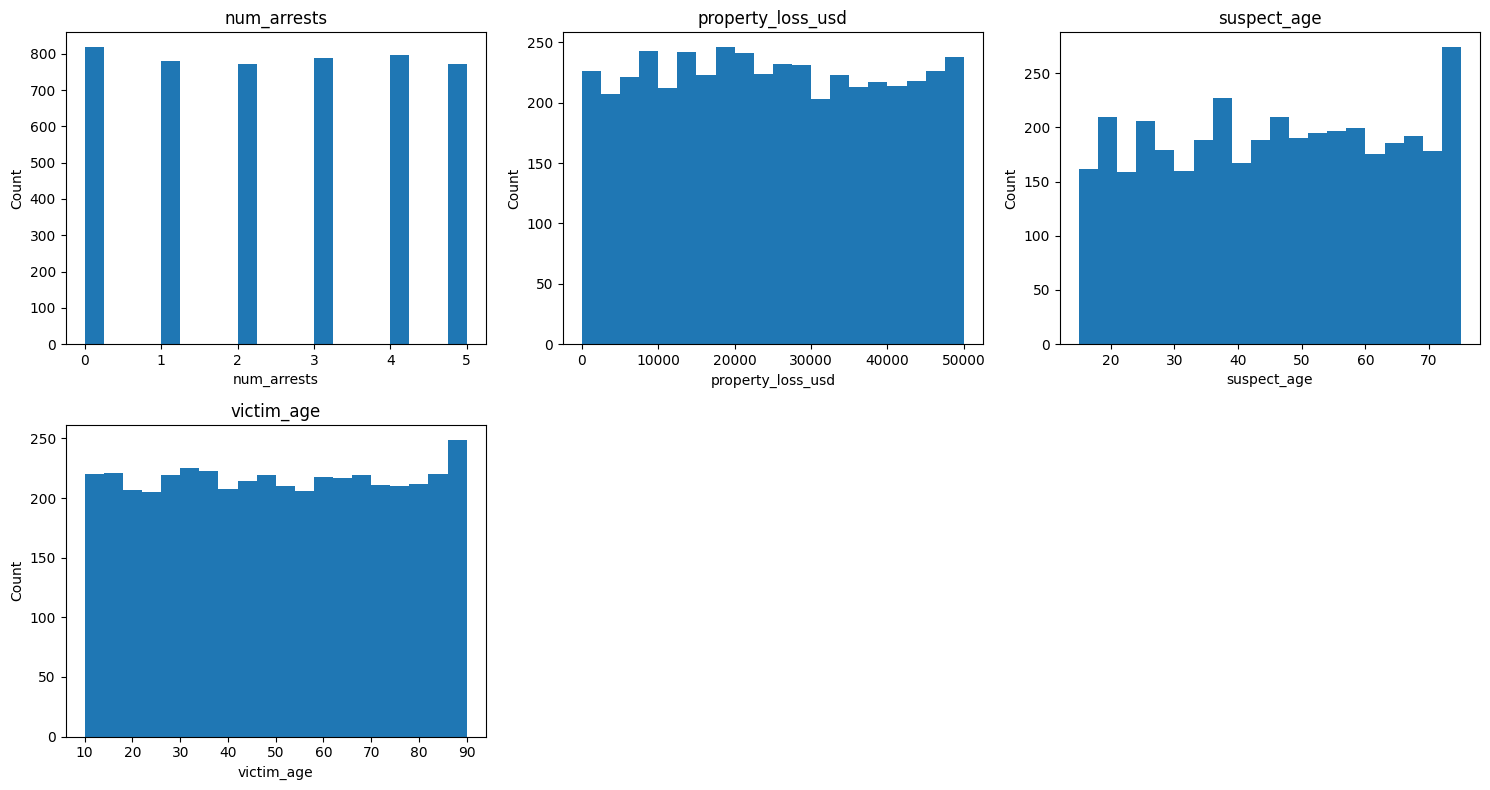

In [12]:
import matplotlib.pyplot as plt
import math

# -------------------------
# CATEGORICAL COLUMNS
# -------------------------

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    df[col].value_counts(dropna=False).plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused empty plots
for j in range(len(categorical_cols), len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()


# -------------------------
# NUMERIC COLUMNS
# -------------------------

nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    df[col].plot(
        kind="hist",
        bins=20,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove unused empty plots
for j in range(len(numeric_cols), len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

## Questions 

### 1 . Identify crime patterns by city 
####  Which cities report the highest number of incidents? Is there a difference in crime type depending on city?

First, I used visualizations and contingency tables to explore crime patterns across cities. Riverside had the highest number of incidents (705). Although total crime counts appeared relatively similar, a chi-square goodness-of-fit test showed that crime counts differed significantly across cities.
Across all cities, Property and Person-related crimes were the most frequent categories (1,653 and 1,625 incidents, respectively). However, a chi-square test of independence found no significant association between city and crime type (p = 0.26), indicating that the relative distribution of crime types was similar across cities.
Conclusion: Total crime volume differed significantly across cities, but the crime-type distribution did not.

city
riverside      705
centerville    661
lakewood       641
springfield    633
oakdale        608
maplewood      604
hillcrest      604
fairview       594
Name: count, dtype: int64


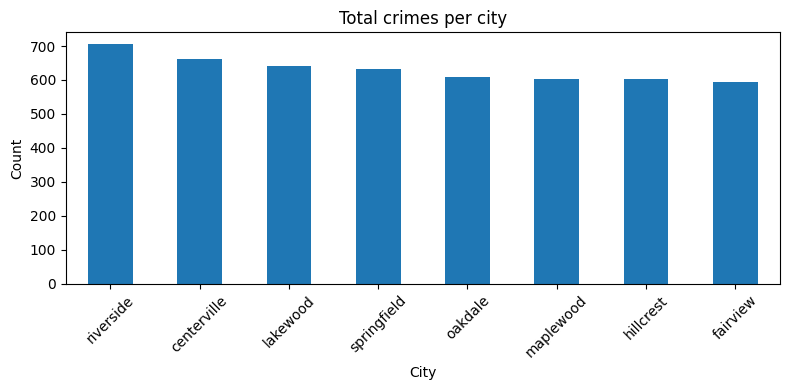


Goodness-of-fit: chi2 = 15.6, df = 7, p = 0.0292


crime_type   financial / cyber  person-related  property  public order / society
city                                                                            
centerville                104             209       210                     138
fairview                    93             198       187                     116
hillcrest                   90             198       207                     109
lakewood                    93             227       199                     122
maplewood                   88             181       192                     143
oakdale                     77             213       198                     120
riverside                  114             208       225                     158
springfield                 87             191       235                     120
TOTAL                      746            1625      1653                    1026


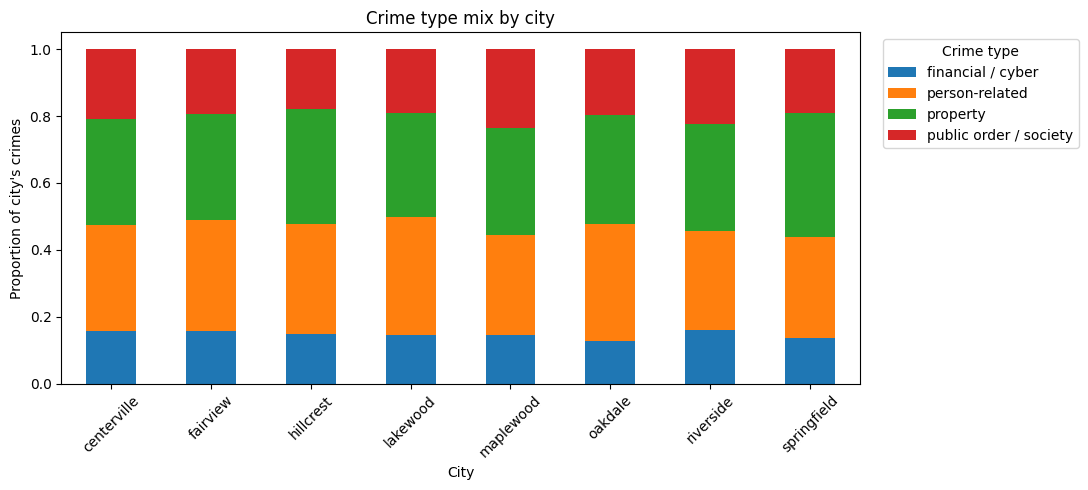


Independence: chi2 = 24.7, df = 21, p = 0.262
Cells with expected count < 5: 0 of 32 


In [ ]:

# =============================================
# check if crime number differs between cities
# =============================================

from scipy.stats import chisquare, chi2_contingency

#  Calculate total crimes per city 
city_counts = df["city"].value_counts() 
print(city_counts)

# visualize the total crimes per city
city_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Total crimes per city")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# perform chi2 goodness-of-fit test
chi2, p = chisquare(city_counts)
print(f"\nGoodness-of-fit: chi2 = {chi2:.1f}, df = {len(city_counts) - 1}, p = {p:.3g}")
print ("\n")

# ============================================================
# check if crime-type proportions differ between cities
# ============================================================
# create a contingency table of crime types by city
table = pd.crosstab(df["city"], df["crime_type"])

# display the contingency table with a total row (if included in the main table, it will be included in the chi2 test)
table_display = table.copy()
table_display.loc["TOTAL"] = table_display.sum(axis=0)

print(table_display)

# plot the percentages of each crime type for each city
table.div(table.sum(axis=1), axis=0).plot(kind="bar", stacked=True, figsize=(11, 5))
plt.title("Crime type mix by city")
plt.xlabel("City")
plt.ylabel("Proportion of city's crimes")
plt.xticks(rotation=45)
plt.legend(title="Crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# perform chi2 test of independence
chi2, p, dof, expected = chi2_contingency(table)
print(f"\nIndependence: chi2 = {chi2:.1f}, df = {dof}, p = {p:.3g}")
print(f"Cells with expected count < 5: {(expected < 5).sum()} of {expected.size} ")